# 03 · VGG16
**Owner:** Mihika Agarwal (230911094)

VGG16 (Simonyan & Zisserman, 2015): 13 convolutional layers in 5 blocks of stacked 3 × 3 convolutions with max pooling, a deep but uniform design that captures fine local texture and edge patterns.

**Interim set-up (unoptimised):** ImageNet weights, backbone frozen, global average pooling,
then the common head Dense(256, ReLU) → Dropout(0.5) → Dense(2, softmax).
Because the backbone is frozen, its pooled features are computed once and cached
(`src/features.py`); only the head is trained. The last cell rebuilds the full end-to-end
model and checks it gives the same predictions as the cached path.

In [1]:
import os, sys
os.environ.setdefault("KERAS_BACKEND", "torch")   # Keras 3 backend used for our runs (CPU); "tensorflow" also works
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))        # make the project's src/ package importable

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import keras
from src import config, data_pipeline as dp, models, features, training

keras.utils.set_random_seed(config.SEED)
print("Keras", keras.__version__, "| backend:", keras.backend.backend())

Keras 3.15.1 | backend: torch


## Pooled features from the frozen backbone (cached)

In [2]:
X_train, y_train, _ = features.extract_features("vgg16", "train")
X_val, y_val, _ = features.extract_features("vgg16", "val")
manifest = pd.read_csv(config.SPLIT_MANIFEST)
class_weight = dp.class_weights(manifest)
print("train", X_train.shape, "val", X_val.shape, "| class weights", class_weight)

Found 4343 images belonging to 2 classes.


136/136 - 869s - 6s/step


vgg16/train: (4343, 512) in 14.5 min (5.0 images/s) -> vgg16_train.npz
Found 1086 images belonging to 2 classes.


34/34 - 204s - 6s/step


vgg16/val: (1086, 512) in 3.4 min (5.3 images/s) -> vgg16_val.npz
train (4343, 512) val (1086, 512) | class weights {0: 2.1185365853658538, 1: 0.654460518384569}


## Model

In [3]:
head = models.build_head(models.head_input_dim(["vgg16"]), name="vgg16_head")
full_model = models.assemble_cnn(["vgg16"], head)
full_model.summary()

Model: "vgg16_full"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mri_224x224 (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg16_base (Functional)         │ (None, 512)            │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg16_head (Functional)         │ (None, 2)              │       131,842 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,846,530 (56.64 MB)

 Trainable params: 131,842 (515.01 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

## Train the classifier head

In [4]:
history = training.train(head, X_train, y_train, X_val, y_val,
                         learning_rate=config.HEAD_LR, class_weight=class_weight)

Epoch 1/30


136/136 - 1s - 6ms/step - accuracy: 0.9024 - loss: 0.4943 - val_accuracy: 0.9724 - val_loss: 0.1070


Epoch 2/30


136/136 - 1s - 5ms/step - accuracy: 0.9643 - loss: 0.1099 - val_accuracy: 0.9558 - val_loss: 0.1725


Epoch 3/30


...

136/136 - 1s - 5ms/step - accuracy: 0.9931 - loss: 0.0249 - val_accuracy: 0.9908 - val_loss: 0.0714


Epoch 18/30


136/136 - 1s - 5ms/step - accuracy: 0.9936 - loss: 0.0162 - val_accuracy: 0.9807 - val_loss: 0.0972


Epoch 19/30


136/136 - 1s - 6ms/step - accuracy: 0.9956 - loss: 0.0142 - val_accuracy: 0.9880 - val_loss: 0.0769


## Validation results

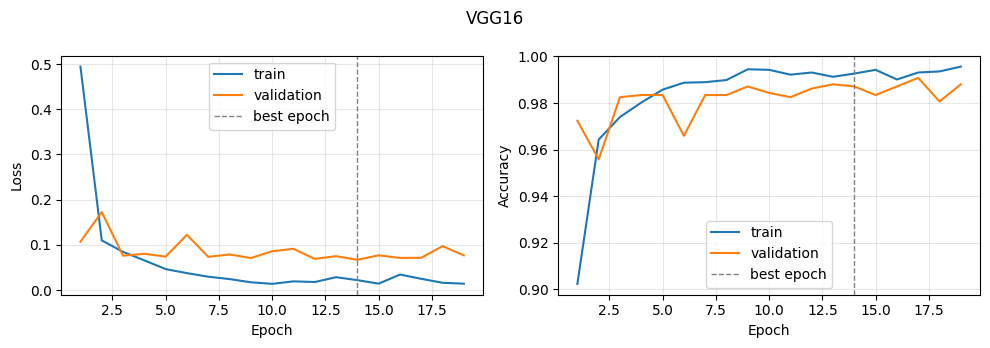

    accuracy: 0.9871
   precision: 0.9916
      recall: 0.9916
 specificity: 0.9727
          f1: 0.9916
    macro_f1: 0.9821
     roc_auc: 0.9974
   confusion: [[TN, FP], [FN, TP]] = [[249, 7], [7, 823]]


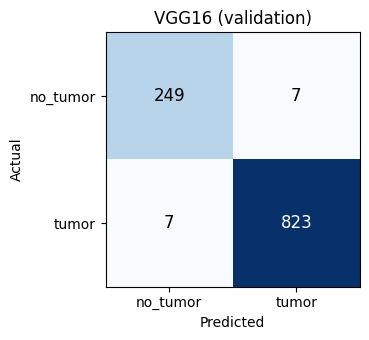

epochs run: 19 | best epoch: 14 | head training time: 14.1 s


In [5]:
training.plot_history(history, "VGG16", config.FIG_DIR / "vgg16_curves.png")
metrics, prob, pred = training.evaluate(head, X_val, y_val)
training.print_metrics(metrics)
training.plot_confusion(metrics["confusion_matrix"], "VGG16 (validation)",
                        config.FIG_DIR / "vgg16_confusion.png")
record = training.save_results("vgg16", metrics, history, head,
                               extra={"total_params_full_model": int(full_model.count_params()),
                                       "learning_rate": config.HEAD_LR})
print("epochs run:", record["epochs_run"], "| best epoch:", record["best_epoch"],
      "| head training time:", record["train_seconds"], "s")

## Sanity check: full model = cached-feature path

In [6]:
xb, _ = dp.make_cnn_generator("val", models.BACKBONES["vgg16"][1])[0]   # first 32 validation images
diff = np.abs(full_model.predict(xb[:16], verbose=0) - head.predict(X_val[:16], verbose=0)).max()
print(f"max |difference| in predicted probabilities: {diff:.2e}")

Found 1086 images belonging to 2 classes.


max |difference| in predicted probabilities: 0.00e+00
